## Uvoz biblioteka
Učitavanje svih potrebnih biblioteka za obradu podataka, vizualizaciju i evaluaciju modela.

**Autor: Valentina**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

## Učitavanje podataka
Učitavamo skalirani i SMOTE-balansirani trening set i test set pripremljene u prvom notebooku.

In [2]:
X_train_sm = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train_sm = pd.read_csv('../data/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print(f"X_train: {X_train_sm.shape}")
print(f"X_test: {X_test.shape}")


X_train: (454902, 30)
X_test: (56962, 30)


## Učitavanje modela
Deserijalizujemo prethodno istrenirani MLP model iz `.pkl` fajla pomoću joblib-a.

In [3]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    max_iter=50,
    random_state=42,
    verbose=False
)

model.fit(X_train_sm, y_train_sm)
print("Model istreniran!")

Model istreniran!


## Predikcija i klasifikacioni izvještaj
Primjenjujemo model na test set i ispisujemo preciznost, odziv i F1 mjeru po klasama.

In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



## Vizualizacija confusion matrice
Grafički prikaz tačnih i pogrešnih klasifikacija modela po kategorijama legitimnih transakcija i prevara.

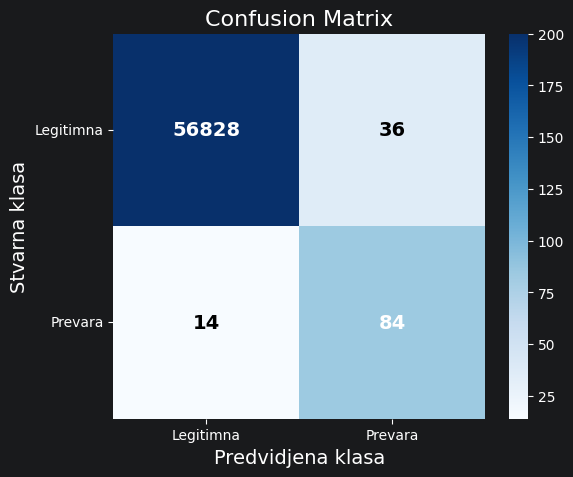

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

sb.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=['Legitimna', 'Prevara'],
    yticklabels=['Legitimna', 'Prevara'],
    cbar=True,
    vmax=200
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j + 0.5,
            i + 0.5,
            str(cm[i, j]),
            ha='center',
            va='center',
            color='white' if cm[i, j] > 40 else 'black',
            fontsize=14,
            fontweight='bold'
        )

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Stvarna klasa', fontsize=14)
plt.xlabel('Predvidjena klasa', fontsize=14)
plt.yticks(rotation=0)
plt.show()

## AUC-ROC metrika i kriva
ROC kriva prikazuje odnos između stope tačno detektovanih prevara i stope lažnih uzbuna, a AUC-ROC broj sumira ukupnu kvalitetu modela.

AUC-ROC: 0.964


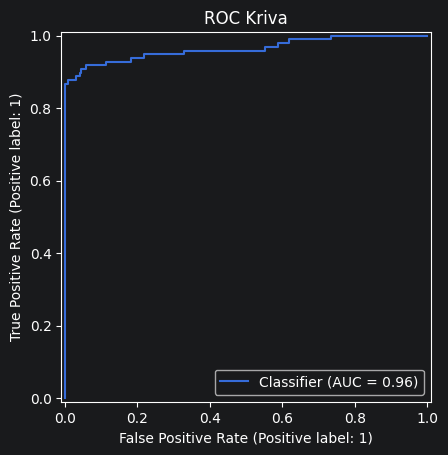

In [6]:
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Kriva')
plt.show()

## Precision-Recall kriva
Precision-Recall kriva je važnija od ROC krive za neuravnotežene datasete — direktno prikazuje kompromis između preciznosti i odziva modela.

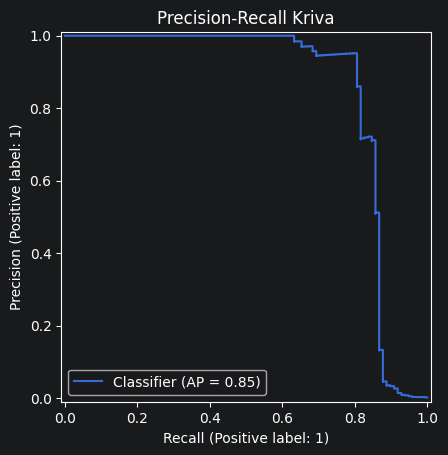

In [7]:
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title('Precision-Recall Kriva')
plt.show()

## Analiza pogrešnih klasifikacija
Pregledamo koliko prevara je propušteno (FN) i koliko je lažnih uzbuna (FP), s detaljnom analizom iznosa propuštenih transakcija.

In [8]:
X_test_reset = X_test.reset_index(drop=True)

pogresno = X_test_reset[(y_test == 1) & (y_pred == 0)]
print(f"Propustenih prevara (False Negative): {len(pogresno)}")
print(f"Laznih uzbuna (False Positive): {((y_test == 0) & (y_pred == 1)).sum()}")
print(f"\nIznosi propustenih prevara:")
print(pogresno['Amount'].describe())

Propustenih prevara (False Negative): 14
Laznih uzbuna (False Positive): 36

Iznosi propustenih prevara:
count    14.000000
mean      0.176694
std       0.940069
min      -0.349231
25%      -0.345393
50%      -0.336677
75%      -0.029404
max       2.185955
Name: Amount, dtype: float64


## Poređenje modela — Logistička regresija vs MLP neuronska mreža
Treniramo logističku regresiju kao baseline model i poredimo rezultate sa MLP neuronskom mrežom.

In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistička regresija")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")

print("\nMLP neuronska mreža")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

Logistička regresija
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC: 0.970

MLP neuronska mreža
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.964


## ROC krive po modelima
Prikazujemo ROC krivu za svaki model posebno.

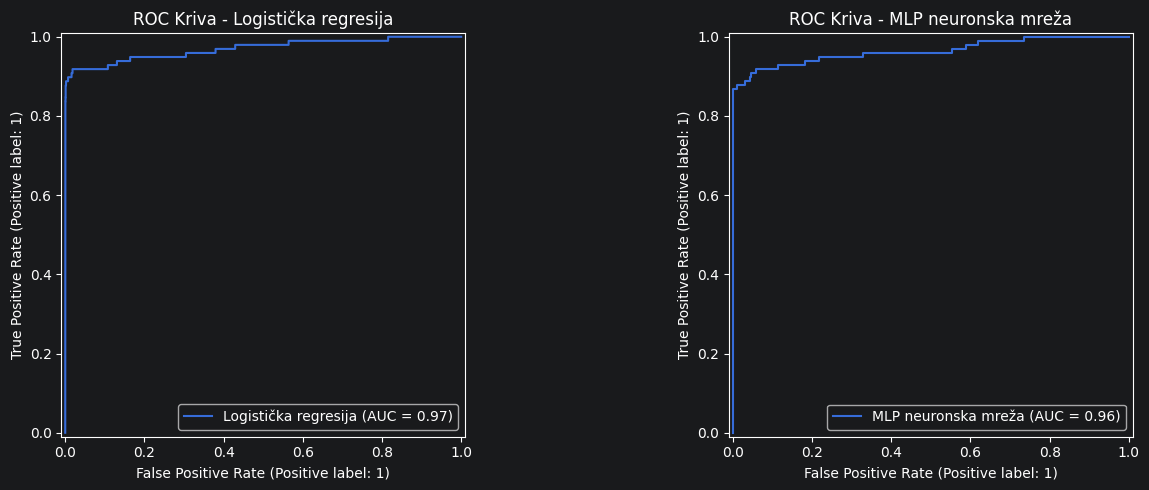

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[0], name='Logistička regresija')
axes[0].set_title('ROC Kriva - Logistička regresija')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='MLP neuronska mreža')
axes[1].set_title('ROC Kriva - MLP neuronska mreža')

plt.tight_layout()
plt.show()

## Kombinovana ROC kriva
Poređenje oba modela na jednom grafiku — jasno se vidi da MLP ima bolji balans između precision i recall uprkos sličnom AUC-u.

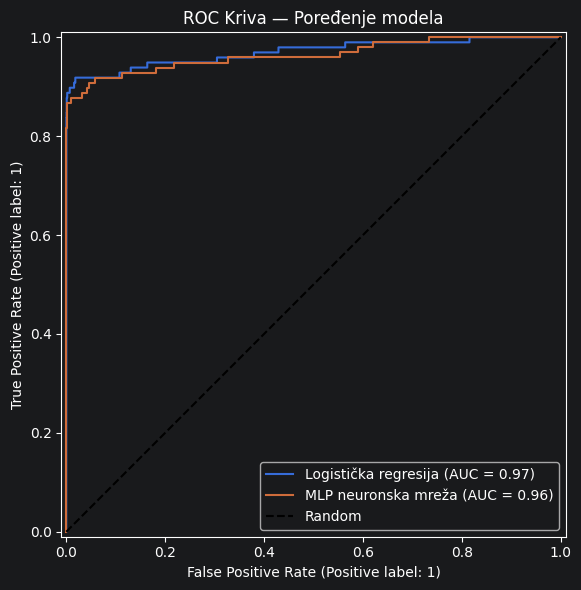

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=ax, name='Logistička regresija')
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name='MLP neuronska mreža')
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Kriva — Poređenje modela')
plt.legend()
plt.tight_layout()
plt.show()